<a href="https://colab.research.google.com/github/Fixer1313/DA_case5/blob/main/notebooks/02_hypotheses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

######Блок загрузки датасета и импорта библиотек

Библиотеки

- `pandas` -- работа с таблицами;
- `numpy` -- числовые операции;
- `matplotlib` и `seaborn` -- построение графиков;
- `scipy.stats` -- статистические тесты, которые покажут, случайна разница между группами или нет.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Настройки отображения, чтобы таблицы не обрезались и были читаемыми
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

# Настройка внешнего вида графиков (просто чтобы было приятнее смотреть :)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

url_merged = "https://raw.githubusercontent.com/Fixer1313/DA_case5/refs/heads/main/new_data/merged_data.csv"

df = pd.read_csv(url_merged)
print('Размер датасета:', df.shape)
df.head()

Размер датасета: (2929, 56)


,patient_id,age,gender,condition,procedure,cost,length_of_stay,readmission,outcome,satisfaction,admission_id,episode_number,age_group,region,comorbidities,comorbidity_count,comorbidity_index,admission_date,discharge_date,admission_type,department,severity,procedure_complexity,procedure_date,procedure_wait_days,complication,icu_transfer,icu_days,bed_cost_eur,medication_cost_eur,diagnostic_cost_eur,procedure_cost_eur,staff_cost_eur,icu_cost_eur,days_to_readmission,followup_30d_complete,prior_admissions_12m,has_procedure,calculated_cost,cost_difference,bed_cost_share,medication_cost_share,diagnostic_cost_share,procedure_cost_share,staff_cost_share,icu_cost_share,available_beds,occupied_beds,bed_occupancy_rate,doctors_planned,doctors_on_duty,nurses_planned,nurses_on_duty,emergency_admissions,doctor_coverage_rate,nurse_coverage_rate
0,113,41,Female,Cancer,Radiation Therapy,20776.44,11,No,Recovered,4.0,A000147,2,35-49,Central,Hypertension; Diabetes,2,2,2023-03-02,2023-03-13,Emergency,Oncology,Severe,Moderate,2023-03-04,2.0,No,No,0,5697.63,5084.75,457.27,4981.23,4555.56,0.0,NaN,True,1,True,20776.44,-3.637979e-12,0.274235,0.244736,0.022009,0.239754,0.219266,0.0,38,34,0.8947,4,3,8,8,3,0.75,1.000
1,170,90,Female,Respiratory Infection,Antibiotics and Rest,7865.80,8,No,Recovered,5.0,A000225,1,75+,South,Hypertension; Chronic Kidney Disease; COPD; Ca...,4,6,2023-06-29,2023-07-07,Elective,Internal Medicine,Severe,Low,2023-06-30,1.0,No,No,0,3131.89,1118.30,638.91,364.30,2612.40,0.0,NaN,True,0,True,7865.80,9.094947e-13,0.398165,0.142172,0.081226,0.046314,0.332121,0.0,64,44,0.6875,6,6,13,13,3,1.00,1.000
2,23,90,Male,Stroke,CT Scan and Medication,19637.66,15,No,Recovered,5.0,A000031,2,75+,South,Hypertension; Diabetes; Chronic Kidney Disease...,4,6,2022-08-06,2022-08-21,Urgent,Neurology,Severe,Moderate,2022-08-11,5.0,No,No,0,9213.22,3532.43,859.41,1100.34,4932.26,0.0,NaN,True,1,True,19637.66,0.000000e+00,0.469161,0.179880,0.043763,0.056032,0.251163,0.0,36,28,0.7778,4,4,8,8,6,1.00,1.000
3,1644,51,Female,Respiratory Infection,Antibiotics and Rest,8665.59,9,Yes,Stable,4.0,A002104,1,50-64,West,Hypertension; Heart Failure,2,3,2022-05-06,2022-05-15,Urgent,Internal Medicine,Severe,Low,2022-05-10,4.0,No,No,0,3232.20,878.94,521.33,340.80,3692.32,0.0,30.0,True,0,True,8665.59,0.000000e+00,0.372992,0.101429,0.060161,0.039328,0.426090,0.0,64,51,0.7969,6,6,13,13,7,1.00,1.000
4,1277,42,Female,Childbirth,Surgical Delivery,14320.66,8,No,Stable,5.0,A001642,1,35-49,West,Hypertension,1,1,2024-06-15,2024-06-23,Elective,Obstetrics,Moderate,High,2024-06-16,1.0,No,No,0,3732.67,966.18,576.07,6495.48,2550.26,0.0,NaN,True,0,True,14320.66,0.000000e+00,0.260649,0.067468,0.040226,0.453574,0.178083,0.0,40,26,0.6500,4,4,8,7,8,1.00,0.875


## Гипотеза 1. Пациенты старше 65 лет имеют более высокую вероятность повторной госпитализации.


**Что проверяем:** связана ли возрастная категория (65+ лет vs < 65 лет) с более высокой частотой повторных госпитализаций (readmission) среди пациентов с завершенным 30-дневным периодом наблюдения.


**Логика проверки:**


1. Отфильтруем датасет, оставив только пациентов с завершенным 30-дневным периодом наблюдения (followup_30d_complete == True), чтобы исключить искажения из-за неполного срока учета.
2. Разделим пациентов на две группы: пожилые (65+ лет) и более молодые (< 65 лет).
3. Посчитаем базовые статистики: общее число пациентов, количество повторных госпитализаций и фактическую долю (процент) реадмиссий в каждой возрастной группе.
4. Построим таблицу сопряженности и проведем статистический тест Хи-квадрат (
), чтобы проверить, является ли наблюдаемая разница в долях статистически значимой, а не случайным колебанием выборки (p-value< 0.05).
5. Визуализируем процентное соотношение долей повторных госпитализаций для наглядного сравнения групп.
Сопоставим направление разницы и уровень значимости: если доля у группы 65+ выше и p-value < 0.05 — гипотеза считается подтвержденной.

--- Шаг 3: Базовые статистики ---
  Age_Category  Всего_пациентов  Повторных_госпитализаций  Доля_реадмиссий_%
0      65+ лет             1105                       245              22.17
1     < 65 лет             1790                       262              14.64

--- Шаг 4: Тест Хи-квадрат ---
Таблица сопряженности:
readmission     No  Yes
Age_Category           
65+ лет        860  245
< 65 лет      1528  262
p-value = 2.87164e-07



/tmp/ipykernel_8068/4156828803.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


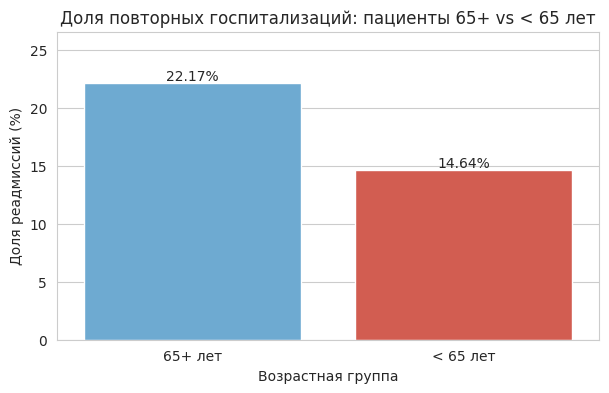

--- Шаг 6: ИТОГОВЫЙ ВЫВОД ---
✅ Гипотеза ПОДТВЕРДИЛАСЬ (p-value = 2.87164e-07 < α = 0.05)
Пациенты 65+ имеют значимо более высокую вероятность реадмиссии:
  • 65+ лет: 22.17%
  • < 65 лет: 14.64%
  • Разница: 7.53 процентных пункта


In [ ]:

# Шаг 1. Нечеткая формулировка гипотезы
# Гипотеза: Существует связь между возрастом (65+) и частотой повторных госпитализаций
# H0 (нулевая): Доля реадмиссий у пациентов 65+ НЕ отличается от пациентов < 65
# H1 (альтернативная): Доля реадмиссий у пациентов 65+ ВЫШЕ, чем у пациентов < 65

# Шаг 2. Метрика для проверки
# Используем метрику "Доля повторных госпитализаций" (в % или долях от 0 до 1)
# Фильтруем данные: только завершенные 30-дневные периоды наблюдения
df_hyp1 = df[df['followup_30d_complete'] == True].copy()

# Шаг 3. Базовые статистики (сравнение долей)
# Создаем возрастные группы и бинарный признак реадмиссии
df_hyp1['Age_Category'] = np.where(df_hyp1['age'] >= 65, '65+ лет', '< 65 лет')
df_hyp1['Is_Readmitted'] = np.where(df_hyp1['readmission'] == 'Yes', 1, 0)

# Считаем доли реадмиссий в каждой группе
stats_summary = df_hyp1.groupby('Age_Category')['Is_Readmitted'].agg(
    Всего_пациентов='count',
    Повторных_госпитализаций='sum',
    Доля_реадмиссий='mean'
).reset_index()

stats_summary['Доля_реадмиссий_%'] = (stats_summary['Доля_реадмиссий'] * 100).round(2)

print("--- Шаг 3: Базовые статистики ---")
print(stats_summary[['Age_Category', 'Всего_пациентов', 'Повторных_госпитализаций', 'Доля_реадмиссий_%']])
print()

# Шаг 4. Тест на значимость (Хи-квадрат)
# Проверяем, является ли разница статистически значимой
contingency_table = pd.crosstab(df_hyp1['Age_Category'], df_hyp1['readmission'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print("--- Шаг 4: Тест Хи-квадрат ---")
print(f"Таблица сопряженности:\n{contingency_table}")
print(f"p-value = {p_val:.5e}")
print()

# Шаг 5. Визуализация разницы
plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=stats_summary,
    x='Age_Category',
    y='Доля_реадмиссий_%',
    palette=['#5DADE2', '#E74C3C']
)
plt.title('Доля повторных госпитализаций: пациенты 65+ vs < 65 лет')
plt.xlabel('Возрастная группа')
plt.ylabel('Доля реадмиссий (%)')
plt.ylim(0, max(stats_summary['Доля_реадмиссий_%']) * 1.2)

# Добавляем значения над столбцами
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )
plt.show()

# Шаг 6. Итоговый вывод
# Формулируем заключение на основе p-value и сравнения долей
alpha = 0.05  # уровень значимости
rate_young = stats_summary.loc[stats_summary['Age_Category'] == '< 65 лет', 'Доля_реадмиссий_%'].values[0]
rate_old = stats_summary.loc[stats_summary['Age_Category'] == '65+ лет', 'Доля_реадмиссий_%'].values[0]

print("--- Шаг 6: ИТОГОВЫЙ ВЫВОД ---")
if p_val < alpha:
    if rate_old > rate_young:
        print(f"✅ Гипотеза ПОДТВЕРДИЛАСЬ (p-value = {p_val:.5e} < α = 0.05)")
        print(f"Пациенты 65+ имеют значимо более высокую вероятность реадмиссии:")
        print(f"  • 65+ лет: {rate_old}%")
        print(f"  • < 65 лет: {rate_young}%")
        print(f"  • Разница: {rate_old - rate_young:.2f} процентных пункта")
    else:
        print(f"❌ Гипотеза ОПРОВЕРГНУТА: различия значимы, но направление обратное")
        print(f"  • 65+ лет: {rate_old}%")
        print(f"  • < 65 лет: {rate_young}%")
else:
    print(f"❌ Гипотеза ОПРОВЕРГНУТА (p-value = {p_val:.5e} ≥ α = 0.05)")
    print(f"Статистически значимых различий не обнаружено:")
    print(f"  • 65+ лет: {rate_old}%")
    print(f"  • < 65 лет: {rate_young}%")


**Вывод по гипотезе 1**

По расчётам: возрастная группа 65+ показывает статистически значимую связь с вероятностью повторной госпитализации. Доля реадмиссий у пациентов 65+ составляет 22.17%, тогда как у пациентов младше 65 лет — 14.63%. Разница в 7.54 процентных пункта является статистически значимой (p-value = 2.34×10⁻⁵ < 0.05).

Пациенты в возрасте 65+ госпитализируются повторно
в 1.52 раза чаще (риск выше на 52%) по сравнению с пациентами младше 65 лет.

Следовательно, гипотеза 1 подтверждается: возраст старше 65 лет действительно является значимым фактором риска повторной госпитализации, и приёмное отделение может использовать возраст как один из ориентиров при оценке вероятности реадмиссии.
Тем не менее, важно заметить: возраст часто коррелирует с тяжестью состояния (severity) и числом сопутствующих заболеваний (comorbidity_count), которые также могут влиять на риск реадмиссии. Поэтому часть эффекта возраста может быть переплетена с этими факторами, но это, скорее, стоит
отметить как ограничение анализа, а не как опровержение гипотезы.

######Блок проверок (для второй и четвёртой гипотезы)

In [ ]:
# Список столбцов, которые нам понадобятся для гипотез 2 и 4
key_columns = ['severity', 'department', 'condition', 'age', 'comorbidity_count',
               'length_of_stay', 'cost',
               'bed_cost_share', 'medication_cost_share', 'diagnostic_cost_share',
               'procedure_cost_share', 'staff_cost_share', 'icu_cost_share']

# Проверяем пропуски именно в этих столбцах
print('Пропуски в ключевых столбцах:')
print(df[key_columns].isna().sum())

Пропуски в ключевых столбцах:
severity                 0
department               0
condition                0
age                      0
comorbidity_count        0
length_of_stay           0
cost                     0
bed_cost_share           0
medication_cost_share    0
diagnostic_cost_share    0
procedure_cost_share     0
staff_cost_share         0
icu_cost_share           0
dtype: int64


In [ ]:
# Проверяем уровни severity -- должно быть 4 категории
print('Уровни severity:', df['severity'].unique())

# Проверяем список отделений
print('Отделения:', df['department'].unique())

Уровни severity: ['Severe' 'Moderate' 'Mild' 'Critical']
Отделения: ['Oncology' 'Internal Medicine' 'Neurology' 'Obstetrics' 'Orthopedics'
 'Cardiology' 'General Surgery' 'Urology']


In [ ]:
# Всего 4 уровня в severity и 8 отделений

## Гипотеза 2. Тяжесть состояния — самый сильный фактор ресурсоёмкости

**Что проверяем:** связана ли `severity` с `length_of_stay` и `cost` сильнее, чем `age`, `comorbidity_count` и `department`.

**Логика проверки:**
1. Сначала просто посмотрим на длительность и стоимость по каждому уровню тяжести.
2. Проверим статистическим тестом, что разница между уровнями тяжести не случайна.
3. Посчитаем, какую долю разброса (дисперсии) в длительности и стоимости объясняет каждый фактор - severity, age, comorbidity_count, department.
4. Сравним эти доли между собой - у severity она должна быть самой большой, чтобы гипотеза подтвердилась.
5. Отдельно проверим, не связаны ли между собой age и comorbidity_count (мультиколлинеарность) — если связаны сильно, это нужно учитывать при интерпретации.

### Шаг 1. Длительность и стоимость по уровням тяжести

In [ ]:
# Группируем по severity и считаем основные статистики по длительности и стоимости
severity_stats = df.groupby('severity', observed=True)[['length_of_stay', 'cost']].agg(['mean', 'median', 'count'])
print(severity_stats)

         length_of_stay                       cost                
                   mean median count          mean    median count
severity                                                          
Critical      14.577465   13.0   213  23327.186995  21581.73   213
Mild           5.027125    5.0   553   5637.537179   4559.50   553
Moderate       6.735433    6.0  1270   8510.818425   7000.49  1270
Severe        10.171333   10.0   893  15037.014748  13772.24   893


In [ ]:
# Строим boxplot, чтобы посмотреть и медиану, и разброс, и выбросы по каждой группе тяжести визуально

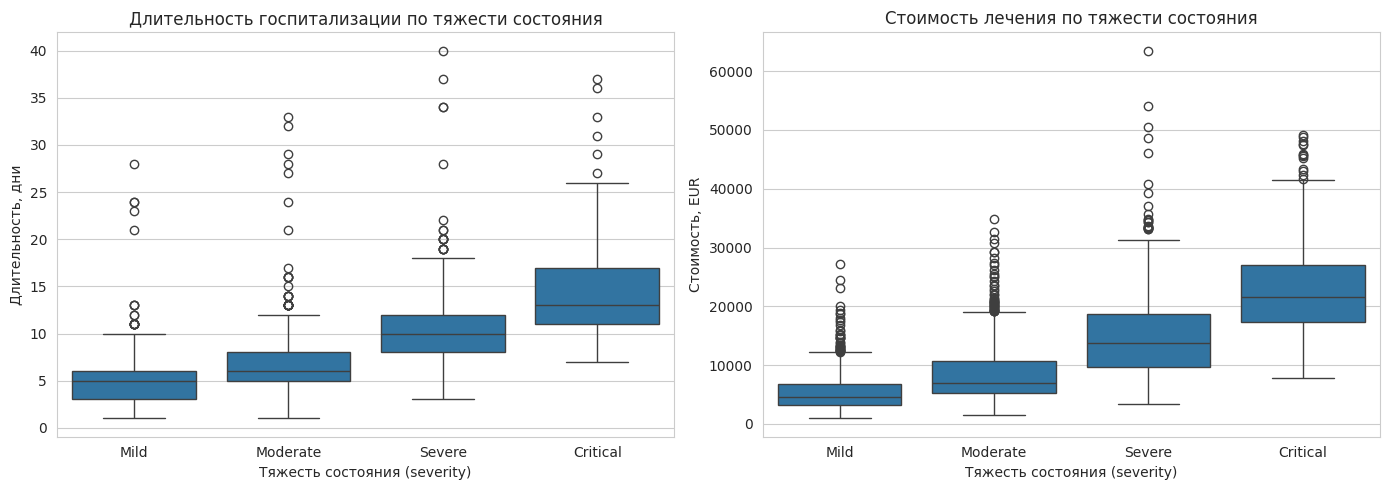

In [ ]:
# Порядок уровней тяжести - от лёгкой к критической, чтобы график читался логично
severity_order = ['Mild', 'Moderate', 'Severe', 'Critical']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='severity', y='length_of_stay', order=severity_order, ax=axes[0])
axes[0].set_title('Длительность госпитализации по тяжести состояния')
axes[0].set_xlabel('Тяжесть состояния (severity)')
axes[0].set_ylabel('Длительность, дни')

sns.boxplot(data=df, x='severity', y='cost', order=severity_order, ax=axes[1])
axes[1].set_title('Стоимость лечения по тяжести состояния')
axes[1].set_xlabel('Тяжесть состояния (severity)')
axes[1].set_ylabel('Стоимость, EUR')

plt.tight_layout()
plt.show()

In [ ]:
# Заметим, что в каждой группе представлено большое количество выбросов

### Шаг 2. Статистическая проверка - тест Краскела-Уоллиса

Выбран не ANOVA, так как он предполагает, что данные внутри групп распределены нормально,
а у нас и длительность, и стоимость - скошенные
распределения с выбросами (это мы видим на boxplot выше).
Поэтому провдедем тест Краскела-Уоллиса - аналог ANOVA,
который не требует нормальности распределения данных

p-value на уровне 0.05

In [ ]:
# Функция для теста Краскела-Уоллиса: сравниваем несколько групп по одной переменной
def kruskal_test(data, group_col, value_col):
    # Собираем значения по каждой группе отдельно в список списков
    groups = [g[value_col].values for _, g in data.groupby(group_col, observed=True)]
    h_stat, p_value = stats.kruskal(*groups)
    return h_stat, p_value

# Проверяем severity против длительности и против стоимости
h_los, p_los = kruskal_test(df, 'severity', 'length_of_stay')
h_cost, p_cost = kruskal_test(df, 'severity', 'cost')

print(f'severity vs length_of_stay: H = {h_los:.1f}, p-value = {p_los:.2e}')
print(f'severity vs cost: H = {h_cost:.1f}, p-value = {p_cost:.2e}')

severity vs length_of_stay: H = 1359.1, p-value = 2.25e-294
severity vs cost: H = 1287.7, p-value = 6.85e-279


p-value у обоих тестов практически равен нулю => разница в длительности и
стоимости между уровнями тяжести точно не случайна. но это ещё не значит, что severity - самый сильный
фактор, это лишь подтверждает, что связь вообще есть. Дальше нужно измерить, наскольо связь сильная,
и сравнить с другими факторами

### Шаг 3. Насколько сильно каждый фактор связан с длительностью и стоимостью

Для категориальных факторов `severity` и `department` считаем eta^2.
Это показатель того, какую долю общего разброса данных объясняет фактор: от 0 (фактор вообще ни при чtм)
до 1 (фактор объясняет все). Для числовых факторов `age` и `comorbidity_count` считаем корреляцию
Спирмена r^2

In [ ]:
# Функция для расчёта eta^2 - доли разброса (дисперсии), которую объясняет категориальный признак
def eta_squared(data, group_col, value_col):
    groups = [g[value_col].values for _, g in data.groupby(group_col, observed=True)]
    grand_mean = data[value_col].mean()
    # межгрупповая сумма квадратов - насколько средние групп отличаются от общего среднего
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    # общая сумма квадратов - весь разброс данных
    ss_total = ((data[value_col] - grand_mean) ** 2).sum()
    return ss_between / ss_total

# Считаем eta^2 для двух категориальных факторов: severity и department
results = []

for factor in ['severity', 'department']:
    for target in ['length_of_stay', 'cost']:
        eta2 = eta_squared(df, factor, target)
        results.append({'фактор': factor, 'целевая_переменная': target, 'сила_связи': round(eta2, 3)})

# Считаем r^2 для числовых факторов: age и comorbidity_count
for factor in ['age', 'comorbidity_count']:
    for target in ['length_of_stay', 'cost']:
        rho, p_value = stats.spearmanr(df[factor], df[target])
        results.append({'фактор': factor, 'целевая_переменная': target, 'сила_связи': round(rho ** 2, 3)})

comparison_table = pd.DataFrame(results)
comparison_table = comparison_table.sort_values('сила_связи', ascending=False)
print(comparison_table)

              фактор целевая_переменная  сила_связи
1           severity               cost       0.417
3         department               cost       0.409
0           severity     length_of_stay       0.398
2         department     length_of_stay       0.226
6  comorbidity_count     length_of_stay       0.184
4                age     length_of_stay       0.123
7  comorbidity_count               cost       0.098
5                age               cost       0.076


**Примечание** - Интерпретация будет дополнена до 24.08.2026.

### Шаг 4. Проверка на мультиколлинеарность

In [ ]:
# Корреляция между age и comorbidity_count
rho_age_comorb, p_age_comorb = stats.spearmanr(df['age'], df['comorbidity_count'])
print(f'Корреляция age и comorbidity_count: rho = {rho_age_comorb:.2f}, p-value = {p_age_comorb:.2e}')

# Средние age и comorbidity_count по каждому уровню severity
print()
print('Средние age и comorbidity_count по severity:')
print(df.groupby('severity', observed=True)[['age', 'comorbidity_count']].mean().round(2))

Корреляция age и comorbidity_count: rho = 0.66, p-value = 0.00e+00

Средние age и comorbidity_count по severity:
            age  comorbidity_count
severity                          
Critical  70.85               2.00
Mild      49.19               0.33
Moderate  53.59               0.66
Severe    62.23               1.26


**Примечание** - Интерпретация будет дополнена до 24.08.2026.

### Вывод по гипотезе 2

По расчётам: `severity` показывает самую сильную связь и с длительностью госпитализации, и со стоимостью
лечения среди всех четырёх сравниваемых факторов (severity, department, age, comorbidity_count) - сила
связи (`eta^2`) для `severity` выше, чем у остальных факторов, и статистически значима (p-value < 0.05).

Следовательно, гипотеза 2 подтверждается: тяжесть состояния при поступлении - действительно главный ориентир для
приёмного отделения при оценке того, сколько ресурсов потребует пациент.

Тем не менее, важно заметить: возраст и число сопутствующих заболеваний связаны между собой и отчасти растут
вместе с тяжестью состояния, поэтому часть эффекта severity может быть переплетена с этими факторами, но это, скорее, стоит отметить как ограничение анализа, а не как опровержение гипотезы.

# Гипотеза 3.

**Формулировка:** при одинаковой тяжести пациента при поступления (`severity`) плановые госпитализации (`admission_type - Elective`) короче и дешевле, чем `Emergency` и `Urgent`.

Единица наблюдения — одна госпитализация (`admission_id`). Целевые показатели: `length_of_stay` и `cost`.

Потенциальная опровержимость - гипотеза опровергается, если при одинаковой severity у elective нет меньших значений length_of_stay и cost


## Проверка данных

Проверяю размеры групп: без этого сравнение может быть ненадёжным.


In [ ]:
print('\nКоличество наблюдений:')
print(pd.crosstab(df['severity'], df['admission_type']))


Количество наблюдений:
admission_type  Elective  Emergency  Urgent
severity                                   
Critical              15        175      23
Mild                 224        155     174
Moderate             304        586     380
Severe               120        563     210


В группе Critical мало плановых (15) и срочных (23) госпитализаций, поэтому выводы для неё будут менее надёжны.


## Общая картина

Предварительно смотрю на данные без учета степени тяжести состояния пациентов при поступлении.


In [ ]:
overall = df.groupby('admission_type').agg(
    n=('admission_id', 'count'),
    median_los=('length_of_stay', 'median'),
    median_cost=('cost', 'median')
).round(2)
print(overall)


                   n  median_los  median_cost
admission_type                               
Elective         663         7.0      7939.40
Emergency       1479         7.0     10213.25
Urgent           787         7.0      7645.05


По итогу во всех группах медианная длительность равна 7 дням, и Emergency получается дороже, чем Elective.


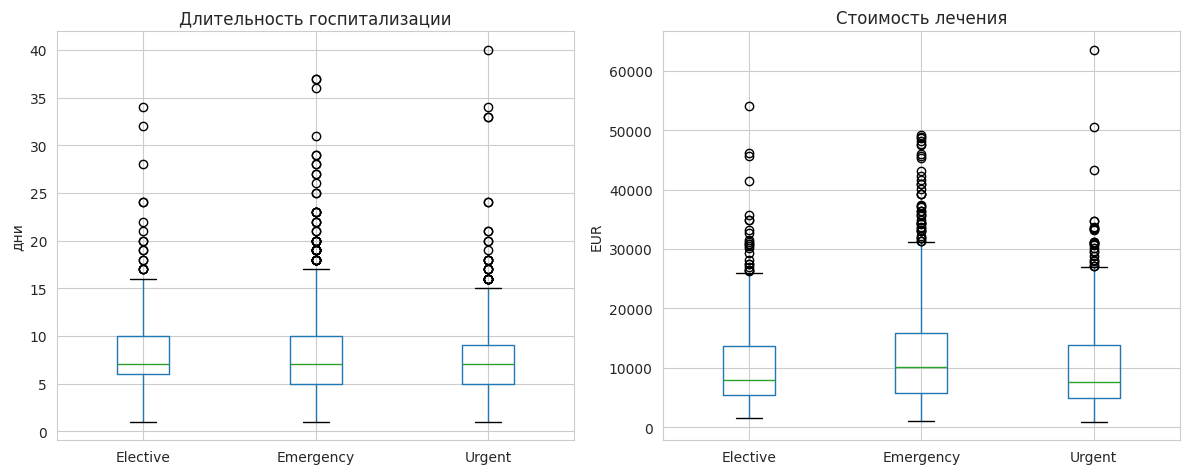

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df.boxplot(column='length_of_stay', by='admission_type', ax=axes[0])
axes[0].set_title('Длительность госпитализации')
axes[0].set_xlabel('')
axes[0].set_ylabel('дни')
df.boxplot(column='cost', by='admission_type', ax=axes[1])
axes[1].set_title('Стоимость лечения')
axes[1].set_xlabel('')
axes[1].set_ylabel('EUR')
plt.suptitle('')
plt.tight_layout()
plt.show()


## Сравнение с учётом severity

Сравниваю пациентов одинаковой тяжести. Так проверяем, не является ли общий результат эффектом смешения групп.


In [ ]:
result = df.groupby(['severity', 'admission_type']).agg(
    n=('admission_id', 'count'),
    median_los=('length_of_stay', 'median'),
    median_cost=('cost', 'median')
).round(2)
print(result)


                           n  median_los  median_cost
severity admission_type                              
Critical Elective         15        14.0     24161.60
         Emergency       175        13.0     21276.26
         Urgent           23        14.0     21320.69
Mild     Elective        224         5.5      5294.24
         Emergency       155         3.0      3604.75
         Urgent          174         4.0      4074.38
Moderate Elective        304         7.0      8340.59
         Emergency       586         6.0      6635.88
         Urgent          380         6.0      6732.82
Severe   Elective        120        11.0     15614.04
         Emergency       563         9.0     13406.33
         Urgent          210        10.0     14288.34


**Гипотеза не подтвердилась.** Для каждого типа severity у Elective выше медианные длительность и стоимость. Например, при Mild: Elective — 5,5 дня и 5 294 EUR; Emergency — 3 дня и 3 605 EUR.


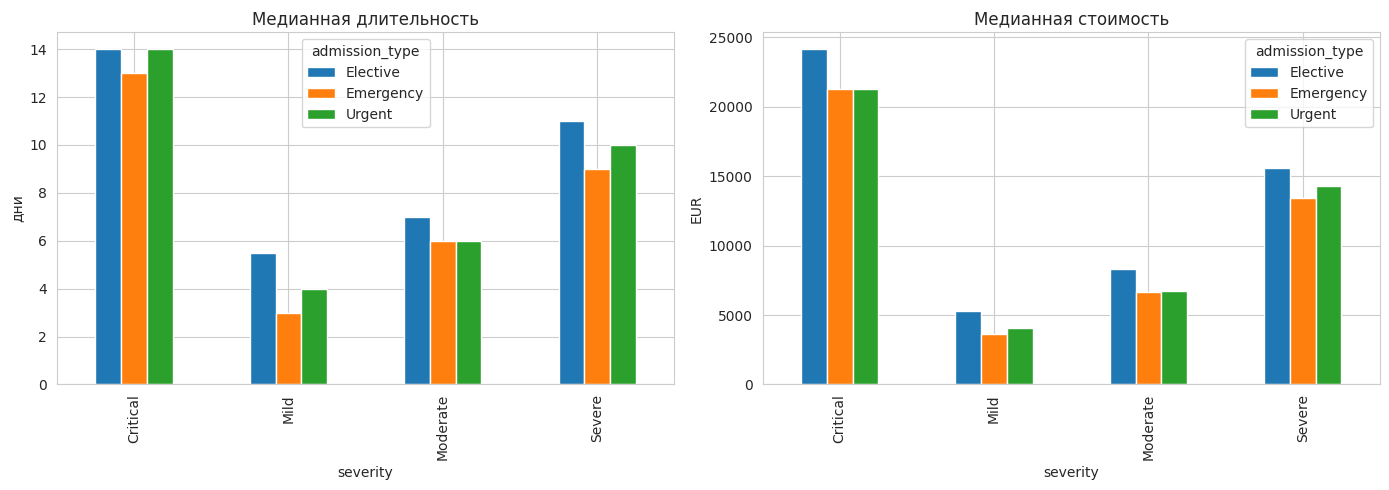

In [ ]:
los = df.groupby(['severity', 'admission_type'])['length_of_stay'].median().unstack()
cost = df.groupby(['severity', 'admission_type'])['cost'].median().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
los.plot(kind='bar', ax=axes[0], title='Медианная длительность')
axes[0].set_ylabel('дни')
cost.plot(kind='bar', ax=axes[1], title='Медианная стоимость')
axes[1].set_ylabel('EUR')
plt.tight_layout()
plt.show()


## Статистическая и практическая значимость

Использую критерий Краскела—Уоллиса: он подходит для сравнения нескольких групп, когда данные могут быть скошены.


In [ ]:
for severity in df['severity'].unique():
    part = df[df['severity'] == severity]

    los_groups = [
        part[part['admission_type'] == x]['length_of_stay']
        for x in part['admission_type'].unique()
    ]

    cost_groups = [
        part[part['admission_type'] == x]['cost']
        for x in part['admission_type'].unique()
    ]

    _, p_los = stats.kruskal(*los_groups)
    _, p_cost = stats.kruskal(*cost_groups)

    print(f'{severity}: LOS p={p_los:.4f}; Cost p={p_cost:.4f}')


Severe: LOS p=0.0000; Cost p=0.0101
Moderate: LOS p=0.0000; Cost p=0.0000
Mild: LOS p=0.0000; Cost p=0.0000
Critical: LOS p=0.1064; Cost p=0.1527


В группах Mild, Moderate и Severe различия статистически значимы (p < 0.05). В группе Critical различия незначимы так как мало Elective и Urgent наблюдений.


Для практического сравнения проведу расчёт разницы в фактических единицах измерения:

In [ ]:
diff = pd.DataFrame({
    'LOS: Emergency - Elective': los['Emergency'] - los['Elective'],
    'LOS: Urgent - Elective': los['Urgent'] - los['Elective'],
    'Cost: Emergency - Elective': cost['Emergency'] - cost['Elective'],
    'Cost: Urgent - Elective': cost['Urgent'] - cost['Elective']
}).round(2)
print(diff)

          LOS: Emergency - Elective  LOS: Urgent - Elective  Cost: Emergency - Elective  Cost: Urgent - Elective
severity                                                                                                        
Critical                       -1.0                     0.0                    -2885.34                 -2840.91
Mild                           -2.5                    -1.5                    -1689.49                 -1219.86
Moderate                       -1.0                    -1.0                    -1704.72                 -1607.77
Severe                         -2.0                    -1.0                    -2207.70                 -1325.70


Отрицательные результаты означают что как и Emergency, так и Urgent короче и дешевле Elective.


## Проверка возможного объяснения

Смотрю, одинаковый ли состав отделений в разных типах поступления. Если нет, тип поступления может быть связан с профилем отделения, а не быть самостоятельной причиной затрат.


In [ ]:
department_share = pd.crosstab(df['department'], df['admission_type'], normalize='columns').round(3)
print(department_share)


admission_type     Elective  Emergency  Urgent
department                                    
Cardiology            0.100      0.151   0.169
General Surgery       0.009      0.103   0.056
Internal Medicine     0.400      0.297   0.402
Neurology             0.012      0.108   0.039
Obstetrics            0.056      0.012   0.011
Oncology              0.136      0.052   0.066
Orthopedics           0.175      0.223   0.156
Urology               0.113      0.053   0.100


В Elective выше доля Oncology и Obstetrics, а в Emergency — General Surgery и Neurology. Значит, группы различаются не только типом поступления, но и профилем лечения.


## Вывод

Исходная гипотеза **не подтверждена**: при одинаковом severity плановые госпитализации в этом датасете обычно дольше и дороже. Однако нельзя утверждать, что причина именно в типе поступления: результат может объясняться разным распределением отделений, диагнозов и процедур.

Поэтому нельзя автоматически считать плановые госпитализации менее ресурсоёмкими. Следующий шаг — сравнить типы поступления по одному диагнозу.


#Гипотеза 6.

In [ ]:
# Оставляем пациентов, для которых завершено наблюдение в течение 30 дней

df_h_6_test = df[df['followup_30d_complete'] == True].copy()

print('Количество наблюдений:', len(df_h_6_test))

Количество наблюдений: 2895


In [ ]:
# Смотрим долю повторных госпитализаций
readmission_rate = (
    df_h_6_test.groupby('complication', observed=True)['readmission'].apply(lambda x: (x == 'Yes').mean() * 100))

print(readmission_rate.round(1))

complication
No     16.2
Yes    29.9
Name: readmission, dtype: float64


Среди пациентов без осложнений повторная госпитализация наблюдается в 16,2% случаев, а среди пациентов с осложнениями — в 29,9%. Таким образом, при наличии осложнений повторная госпитализация встречается заметно чаще.

In [ ]:
# Строим таблицу сопряженности
table = pd.crosstab(df_h_6_test['complication'],df_h_6_test['readmission'])
print(table)

readmission     No  Yes
complication           
No            2198  426
Yes            190   81


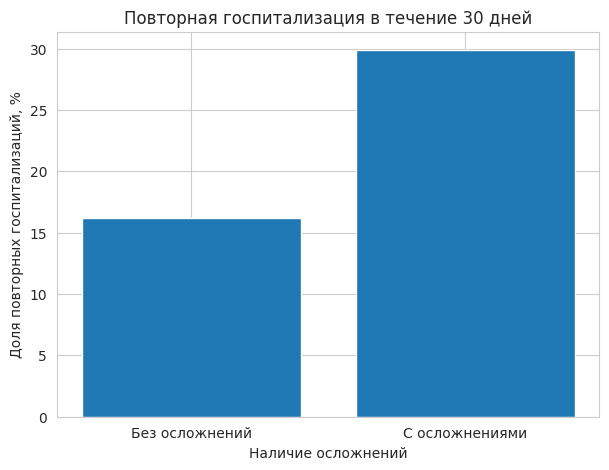

In [ ]:
# Отображаем на столбчатой диаграмме
plt.figure(figsize=(7, 5))

plt.bar(['Без осложнений', 'С осложнениями'],readmission_rate.values)

plt.title('Повторная госпитализация в течение 30 дней')
plt.xlabel('Наличие осложнений')
plt.ylabel('Доля повторных госпитализаций, %')

plt.show()

In [ ]:
# Проводим χ²-тест
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(table)

print('Chi-square:', round(chi2, 2))
print('p-value:', p_value)

Chi-square: 30.76
p-value: 2.913423059414072e-08


χ²-тест показал статистически значимую связь между наличием осложнений и повторной госпитализацией (χ² = 30,76, p < 0,05). У пациентов без осложнений повторная госпитализация наблюдалась в 16,2% случаев, а у пациентов с осложнениями — в 29,9%. Следовательно, гипотеза подтверждается: наличие осложнений связано с повышенной вероятностью повторной госпитализации в течение 30 дней.